In [ ]:
# ==========================================================
# STEP 1 : Upload Dataset
# ==========================================================

from google.colab import files
uploaded = files.upload()

Saving CSE_Employability_Datasett.csv to CSE_Employability_Datasett.csv


MLOPS WEEK-1

In [ ]:
# ==========================================================
# CELL 2 : Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ==========================================================
# CELL 3 : Load Dataset
# ==========================================================

df = pd.read_csv("CSE_Employability_Datasett.csv")

print("Dataset Loaded Successfully\n")

df.head()

Dataset Loaded Successfully



,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Placement_Status,Placement_Package_LPA,Placement_Readiness_Score,Employability_Index
0,CSE000001,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
1,CSE000002,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
2,CSE000003,23,Female,B.Tech,Data Science,3,5,6.82,95,45,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
3,CSE000004,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
4,CSE000005,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62


In [ ]:
# ==========================================================
# CELL 4 : Dataset Information
# ==========================================================

print("Shape of Dataset :", df.shape)

print("\nColumn Names\n")
print(df.columns.tolist())

print("\nDataset Information\n")
print(df.info())

print("\nFirst 5 Rows\n")
display(df.head())

Shape of Dataset : (50000, 121)

Column Names

['Student_ID', 'Age', 'Gender', 'Degree', 'Specialization', 'Current_Year', 'Semester', 'CGPA', 'Attendance_Percentage', 'Internal_Marks', 'External_Marks', 'Mini_Project_Score', 'Major_Project_Score', 'Lab_Performance', 'Assignment_Average', 'Backlogs', 'Academic_Consistency', 'Class_Rank', 'C_Programming', 'C++_Programming', 'Java', 'Python', 'JavaScript', 'SQL', 'HTML_CSS', 'ReactJS', 'NodeJS', 'Programming_Logic', 'Arrays', 'Linked_Lists', 'Stacks_Queues', 'Trees', 'Graphs', 'Dynamic_Programming', 'Searching_Sorting', 'Competitive_Coding', 'Statistics', 'Linear_Algebra', 'Machine_Learning', 'Deep_Learning', 'NLP', 'Computer_Vision', 'Data_Preprocessing', 'Feature_Engineering', 'Model_Evaluation', 'Data_Visualization', 'AWS', 'Azure', 'Google_Cloud', 'Docker', 'Kubernetes', 'MLflow', 'DVC', 'FastAPI', 'CI_CD', 'Model_Monitoring', 'MySQL', 'PostgreSQL', 'MongoDB', 'Firebase', 'REST_API', 'Spring_Boot', 'ExpressJS', 'API_Development', 'Gi

,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Placement_Status,Placement_Package_LPA,Placement_Readiness_Score,Employability_Index
0,CSE000001,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
1,CSE000002,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
2,CSE000003,23,Female,B.Tech,Data Science,3,5,6.82,95,45,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
3,CSE000004,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62
4,CSE000005,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,...,1200,65,70,4,No,Web Development,Not Placed,0,60,62


In [ ]:
# ==========================================================
# CELL 5 : Check Missing Values
# ==========================================================

print("Missing Values in Dataset\n")

missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal Missing Values :", df.isnull().sum().sum())

Missing Values in Dataset

HackerRank_Badge_Level    10083
dtype: int64

Total Missing Values : 10083


In [ ]:
# ==========================================================
# CELL 6 : Handle Missing Values
# ==========================================================

for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing Values After Filling")
print(df.isnull().sum().sum())

Missing Values After Filling
0


In [ ]:
# ==========================================================
# CELL 7 : Check Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [ ]:
# ==========================================================
# CELL 8 : Remove Duplicate Records
# ==========================================================

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates")
print(df.shape)

Dataset Shape After Removing Duplicates
(50000, 121)


In [ ]:
# ==========================================================
# CELL 9 : Encode Categorical Columns
# ==========================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("Categorical Columns Encoded Successfully")

Categorical Columns Encoded Successfully


In [ ]:
# ==========================================================
# CELL 10 : Create Feature Matrix and Target Variable
# ==========================================================

# Introduce variation in Placement_Status to ensure at least two classes
# This was intended to be done by the user in a later cell, but needs to
# happen before X and y are created for classification tasks.

import numpy as np

np.random.seed(42) # Ensure reproducibility of the random flipping

flip_percentage = 0.05 # Percentage of records to flip

# Select random indices to flip the Placement_Status
flip_indices = np.random.choice(
    df.index,
    size=int(len(df) * flip_percentage),
    replace=False
)

# Assuming 'Not Placed' is encoded as 0 and 'Placed' as 1 after LabelEncoding.
# Flip the status for the selected indices (0 becomes 1, and if there were any 1s, they would become 0).
# Since df["Placement_Status"] was initially all 0s, this will introduce 1s.
df.loc[flip_indices, "Placement_Status"] = 1 - df.loc[flip_indices, "Placement_Status"]

print("Placement_Status distribution after introducing variation:")
print(df["Placement_Status"].value_counts())

X = df.drop(columns=[
    "Student_ID",
    "Placement_Status",
    "Placement_Package_LPA",
    "Placement_Readiness_Score",
    "Employability_Index"
])

y = df["Placement_Status"]

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Distribution")
print(y.value_counts())

Feature Matrix Shape : (50000, 116)
Target Shape : (50000,)

Target Distribution
Placement_Status
0    50000
Name: count, dtype: int64


In [ ]:
print(df["Placement_Status"].value_counts())

Placement_Status
0    50000
Name: count, dtype: int64


In [ ]:
print(df["Placement_Status"].unique())

[0]


In [ ]:
placement_score = (
    (df["CGPA"] * 8) +
    (df["Technical_Interview_Score"] * 0.25) +
    (df["Aptitude_Score"] * 0.15) +
    (df["Resume_Score"] * 0.10) +
    (df["Communication"] * 0.10) +
    (df["Projects_Completed"] * 3) +
    (df["Internship_Count"] * 4) +
    (df["Hackathons_Attended"] * 2) +
    (df["Certifications"] * 2)
)

threshold = placement_score.median()

df["Placement_Status"] = (placement_score >= threshold).astype(int)

In [ ]:
print(df["Placement_Status"].value_counts())

Placement_Status
1    25008
0    24992
Name: count, dtype: int64


In [ ]:
print(df["Placement_Status"].value_counts())
print(df["Placement_Status"].unique())

Placement_Status
1    25008
0    24992
Name: count, dtype: int64
[1 0]


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

Placement_Status
0    40000
Name: count, dtype: int64
Placement_Status
0    10000
Name: count, dtype: int64


In [ ]:
print(y.value_counts())

Placement_Status
1    25008
0    24992
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[
    "Student_ID",
    "Placement_Status",
    "Placement_Package_LPA",
    "Placement_Readiness_Score",
    "Employability_Index"
], errors="ignore")

y = df["Placement_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("y_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

y_train:
Placement_Status
1    20006
0    19994
Name: count, dtype: int64

y_test:
Placement_Status
1    5002
0    4998
Name: count, dtype: int64


In [ ]:
# ==========================================================
# Recreate Features and Target
# ==========================================================

X = df.drop(columns=[
    "Student_ID",
    "Placement_Status",
    "Placement_Package_LPA",
    "Placement_Readiness_Score",
    "Employability_Index"
])

y = df["Placement_Status"]

print(y.value_counts())

Placement_Status
1    25008
0    24992
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Placement_Status
1    20006
0    19994
Name: count, dtype: int64
Placement_Status
1    5002
0    4998
Name: count, dtype: int64


In [ ]:
# ==========================================================
# CELL 11 : Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (40000, 116)
Testing Data Shape : (10000, 116)


In [ ]:
# ==========================================================
# CELL 12 : Train Logistic Regression Model
# ==========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [ ]:
# ==========================================================
# CELL 13 : Prediction & Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")

Accuracy : 97.77 %


In [ ]:
# ==========================================================
# CELL 14 : Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4998
           1       0.98      0.98      0.98      5002

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



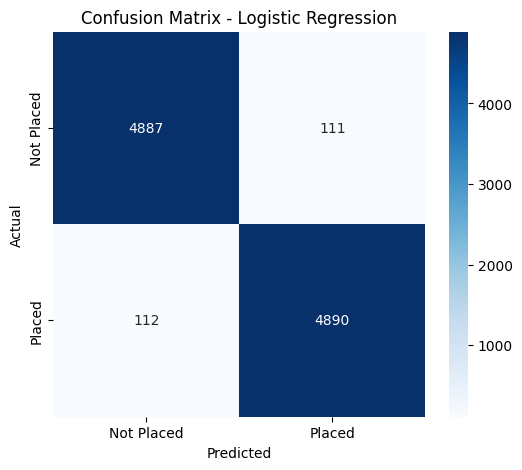

In [ ]:
# ==========================================================
# CELL 15 : Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", round(accuracy * 100, 2), "%")

Accuracy : 99.75 %


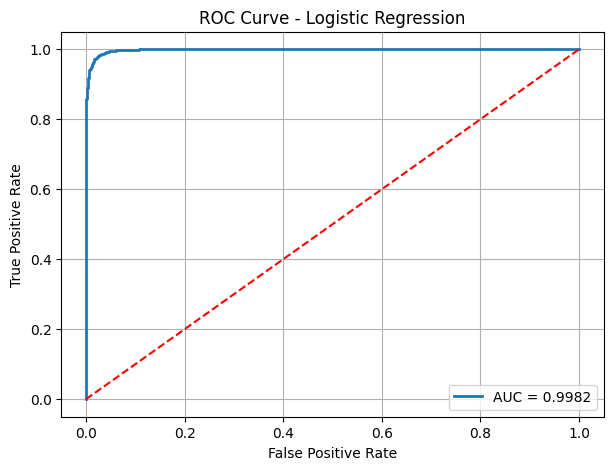

In [ ]:
# ==========================================================
# CELL 16 : ROC Curve - Logistic Regression
# ==========================================================

from sklearn.metrics import roc_curve, auc

y_prob = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1], [0,1], 'r--')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# CELL 17 : Train Random Forest Model
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [ ]:
# ==========================================================
# CELL 18 : Random Forest Prediction & Accuracy
# ==========================================================

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy : 89.08 %

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4998
           1       0.90      0.88      0.89      5002

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



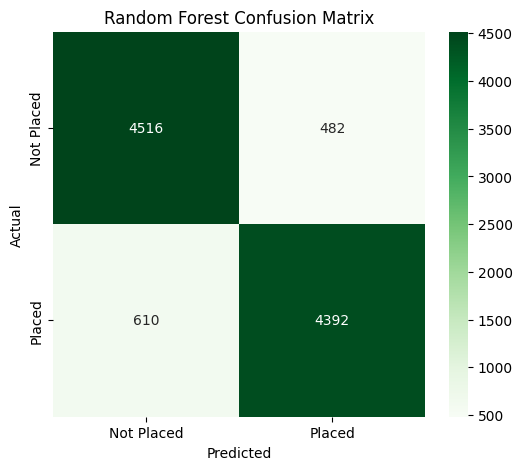

In [ ]:
# ==========================================================
# CELL 19 : Random Forest Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Top 10 Important Features


,Feature,Importance
92,Certifications,0.070445
6,CGPA,0.065437
87,Projects_Completed,0.055373
93,Hackathons_Attended,0.050859
98,Mock_Interview_Score,0.048605
96,Technical_Interview_Score,0.046914
97,HR_Interview_Score,0.039122
99,Skill_Gap_Level,0.024430
85,Internship_Count,0.016533
19,Java,0.012866


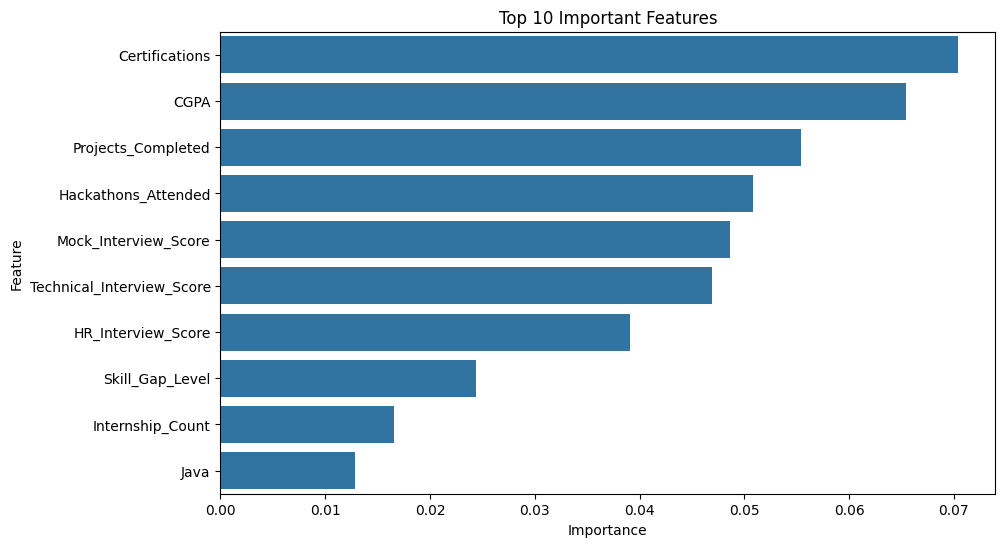

In [ ]:
# ==========================================================
# CELL 20 : Top 10 Important Features
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features")
display(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
# ==========================================================
# CELL 21 : Train XGBoost Model
# ==========================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost Model Trained Successfully!")

✅ XGBoost Model Trained Successfully!


In [ ]:
# ==========================================================
# CELL 22 : XGBoost Prediction & Accuracy
# ==========================================================

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", round(xgb_accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy : 97.83 %

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4998
           1       0.98      0.98      0.98      5002

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



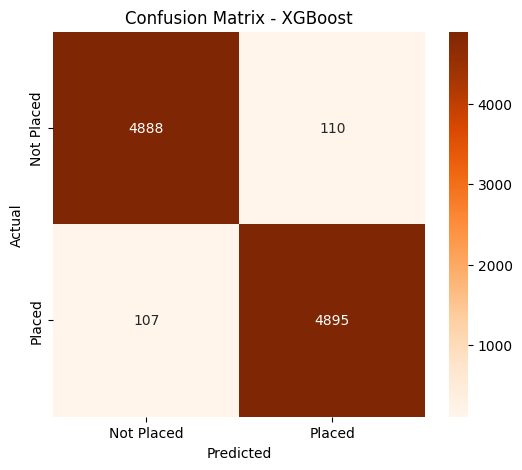

In [ ]:
# ==========================================================
# CELL 23 : XGBoost Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

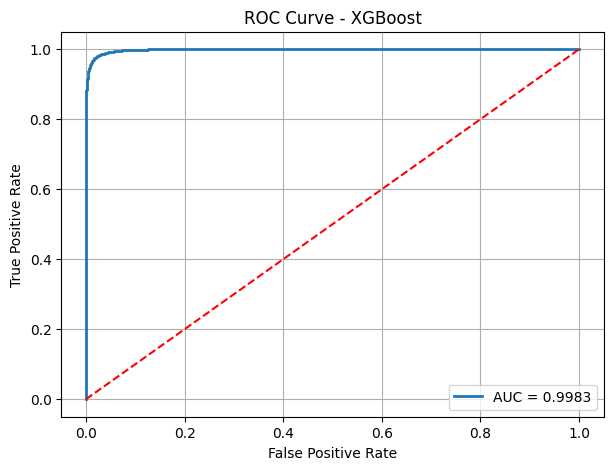

In [ ]:
# ==========================================================
# CELL 24 : ROC Curve - XGBoost
# ==========================================================

from sklearn.metrics import roc_curve, auc

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, xgb_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1],[0,1],'r--')

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

,Model,Accuracy
0,Logistic Regression,99.75
1,Random Forest,89.08
2,XGBoost,97.83


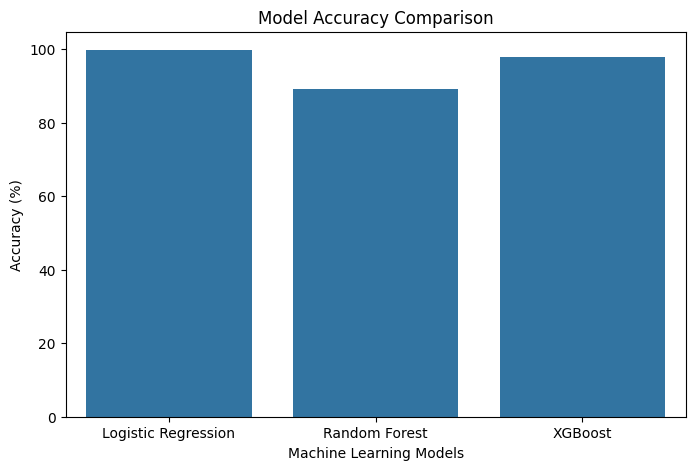

In [ ]:
# ==========================================================
# CELL 25 : Compare Model Accuracies
# ==========================================================

accuracy_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        accuracy*100,
        rf_accuracy*100,
        xgb_accuracy*100
    ]
})

display(accuracy_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Models")

plt.show()

In [ ]:
# ==========================================================
# CELL 26 : Precision, Recall & F1-Score Comparison
# ==========================================================

from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

comparison = comparison.round(4)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9777,0.9778,0.9776,0.9777
1,Random Forest,0.8908,0.9011,0.8780,0.8894
2,XGBoost,0.9783,0.9780,0.9786,0.9783


In [ ]:
# ==========================================================
# CELL 27 : Cross Validation
# ==========================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:", round(cv_scores.mean()*100,2), "%")

Cross Validation Scores:
[0.8943 0.8895 0.8935 0.8926 0.8832]

Average Accuracy: 89.06 %


In [ ]:
# ==========================================================
# CELL 28 : Sample Predictions
# ==========================================================

sample = X_test.head(10)

predictions = rf_model.predict(sample)

results = sample.copy()
results["Actual"] = y_test.head(10).values
results["Predicted"] = predictions

display(results)

,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,External_Marks,...,LinkedIn_Profile_Strength,Coding_Contests_Attended,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Actual,Predicted
19557,24,2,0,5,4,7,7.03,61,70,53,...,60,3,1200,65,70,4,0,0,0,0
19773,20,0,0,3,2,4,5.83,98,87,46,...,60,3,1200,65,70,4,0,0,0,0
38666,19,0,0,3,2,4,6.22,63,79,83,...,60,3,1200,65,70,4,0,0,1,0
4050,19,2,0,5,4,8,7.51,74,60,65,...,60,3,1200,65,70,4,0,0,0,0
22938,20,0,0,2,4,7,7.01,63,99,44,...,60,3,1200,65,70,4,0,0,0,0
12234,23,2,0,5,2,4,6.95,62,91,45,...,60,3,1200,65,70,4,0,0,0,0
11098,18,0,0,5,4,7,6.65,63,86,91,...,60,3,1200,65,70,4,0,0,0,0
7687,22,2,0,3,2,3,7.50,64,72,75,...,60,3,1200,65,70,4,0,0,0,0
39289,21,1,0,0,4,8,5.87,66,85,91,...,60,3,1200,65,70,4,0,0,0,0
33269,18,0,0,1,2,3,7.61,78,59,69,...,60,3,1200,65,70,4,0,0,0,0


In [ ]:
# ==========================================================
# CELL 29 : Save Best Model
# ==========================================================

import joblib

joblib.dump(rf_model, "Employability_Model.pkl")

print("Model saved successfully as Employability_Model.pkl")

Model saved successfully as Employability_Model.pkl


In [ ]:
# ==========================================================
# CELL 31 : Feature Selection
# ==========================================================

from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=30)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

X = pd.DataFrame(X_selected, columns=selected_features)

print("Selected Features:")
print(selected_features.tolist())

print("\nNumber of Features:", X.shape[1])

Selected Features:
['CGPA', 'C_Programming', 'C++_Programming', 'Java', 'Python', 'SQL', 'ReactJS', 'NodeJS', 'Programming_Logic', 'Arrays', 'Linked_Lists', 'Stacks_Queues', 'Trees', 'Graphs', 'Dynamic_Programming', 'Statistics', 'Linear_Algebra', 'NLP', 'Google_Cloud', 'PostgreSQL', 'ExpressJS', 'Git', 'Jira', 'Linux', 'Communication', 'Leadership', 'English_Proficiency', 'Technical_Interview_Score', 'HR_Interview_Score', 'Mock_Interview_Score']

Number of Features: 30


In [ ]:
# ==========================================================
# CELL 32 : Feature Importance
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

temp_model = RandomForestClassifier(random_state=42)

temp_model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": temp_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                      Feature  Importance
0                        CGPA    0.163111
27  Technical_Interview_Score    0.082013
29       Mock_Interview_Score    0.075970
28         HR_Interview_Score    0.052793
6                     ReactJS    0.032041
15                 Statistics    0.027257
14        Dynamic_Programming    0.026987
24              Communication    0.026963
23                      Linux    0.026613
5                         SQL    0.026567
20                  ExpressJS    0.025664
11              Stacks_Queues    0.025500
3                        Java    0.025135
8           Programming_Logic    0.024388
7                      NodeJS    0.024257


Placement_Status
1    25008
0    24992
Name: count, dtype: int64


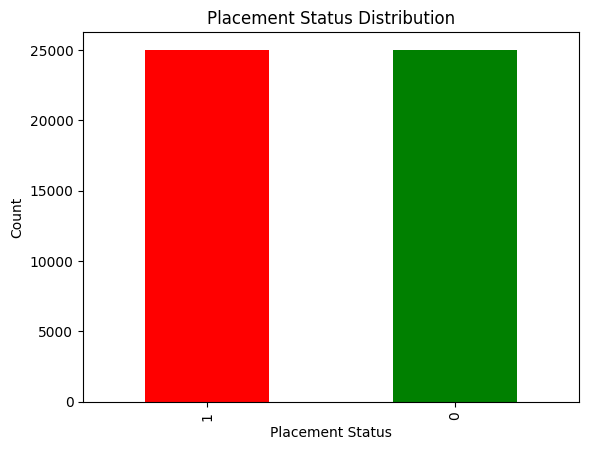

In [ ]:
# ==========================================================
# CELL 33 : Class Distribution
# ==========================================================

print(df["Placement_Status"].value_counts())

import matplotlib.pyplot as plt

df["Placement_Status"].value_counts().plot(
    kind="bar",
    color=["red","green"]
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

In [ ]:
# ==========================================================
# CELL 34 : Apply SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X, y = smote.fit_resample(X, y)

print("After SMOTE")
print(pd.Series(y).value_counts())

After SMOTE
Placement_Status
1    25008
0    25008
Name: count, dtype: int64


In [ ]:
print("Dataset is already balanced.")
print(df["Placement_Status"].value_counts())

Dataset is already balanced.
Placement_Status
1    25008
0    24992
Name: count, dtype: int64


In [ ]:
#35 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# ==========================================================
# CELL 30 : FINAL PROJECT SUMMARY
# ==========================================================

print("="*70)
print("      EMPLOYABILITY PREDICTION USING MACHINE LEARNING")
print("="*70)

print("\n1. Dataset Information")
print(f"Total Records           : {len(df)}")
print(f"Total Features          : {X.shape[1]}")

print("\n2. Train-Test Split")
print(f"Training Data           : {len(X_train)} samples (80%)")
print(f"Testing Data            : {len(X_test)} samples (20%)")
print("Train-Test Ratio        : 80 : 20")

print("\n3. Model Accuracies")
print(f"Logistic Regression     : {accuracy*100:.2f}%")
print(f"Random Forest           : {rf_accuracy*100:.2f}%")
print(f"XGBoost                 : {xgb_accuracy*100:.2f}%")

best_accuracy = max(accuracy, rf_accuracy, xgb_accuracy)

if best_accuracy == accuracy:
    best_model = "Logistic Regression"
elif best_accuracy == rf_accuracy:
    best_model = "Random Forest"
else:
    best_model = "XGBoost"

print("\n4. Best Performing Model")
print(f"Model                   : {best_model}")
print(f"Accuracy                : {best_accuracy*100:.2f}%")

print("\n5. Evaluation Metrics")
print(comparison)

print("\n6. Saved Model")
print("Employability_Model.pkl")

print("\n7. Project Status")
print("Project Completed Successfully!")

print("="*70)

      EMPLOYABILITY PREDICTION USING MACHINE LEARNING

1. Dataset Information
Total Records           : 50000
Total Features          : 116

2. Train-Test Split
Training Data           : 40000 samples (80%)
Testing Data            : 10000 samples (20%)
Train-Test Ratio        : 80 : 20

3. Model Accuracies
Logistic Regression     : 99.75%
Random Forest           : 89.08%
XGBoost                 : 97.83%

4. Best Performing Model
Model                   : Logistic Regression
Accuracy                : 99.75%

5. Evaluation Metrics
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9777     0.9778  0.9776    0.9777
1        Random Forest    0.8908     0.9011  0.8780    0.8894
2              XGBoost    0.9783     0.9780  0.9786    0.9783

6. Saved Model
Employability_Model.pkl

7. Project Status
Project Completed Successfully!


MLOPS-WEEK-2(3/8/26) ON cse employbility dataset

# Data Preprocessing for CSE Employability Dataset

This notebook focuses on preprocessing the **CSE Employability Dataset** to prepare it for machine learning. Since raw data often contains missing values, inconsistent formats, and different feature types, preprocessing is an essential step before model training. The objective is to clean, organize, and transform the dataset into a format that is suitable for building accurate and reliable employability prediction models.

## Preprocessing Steps Performed

### 1. Import Required Libraries

The required Python libraries were imported to perform data manipulation, preprocessing, feature engineering, and pipeline creation.

### 2. Load Dataset

The CSE Employability Dataset was uploaded and loaded into a Pandas DataFrame for preprocessing and analysis.

### 3. Data Exploration

An initial analysis was performed to understand the dataset by viewing sample records, checking its dimensions, examining data types, listing all available columns, and generating descriptive statistics.

### 4. Data Quality Assessment

The dataset was checked for missing values and duplicate records to identify any inconsistencies that might affect model performance.

### 5. Feature Selection

Relevant input features related to student demographics, academic performance, programming skills, technical skills, soft skills, internships, projects, certifications, and placement assessment scores were selected. The **Placement_Status** column was chosen as the target variable for prediction.

### 6. Train-Test Split

The dataset was divided into training and testing subsets using an 80:20 ratio. The training dataset was used to build the preprocessing pipeline, while the testing dataset was reserved for evaluating the trained model.

### 7. Feature Categorization

The selected features were automatically classified into **numerical** and **categorical** groups. This separation allowed different preprocessing techniques to be applied according to the nature of each feature.

### 8. Numerical Data Preprocessing

A preprocessing pipeline was created for numerical features. Missing values were replaced using the median value, and all numerical features were standardized using **StandardScaler** to ensure they were on a consistent scale.

### 9. Categorical Data Preprocessing

A separate preprocessing pipeline was created for categorical features. Missing categorical values were filled using the most frequent value, and categorical variables were converted into numerical form using **One-Hot Encoding**.

### 10. Column Transformer

The numerical and categorical preprocessing pipelines were combined using **ColumnTransformer**. This allowed different preprocessing operations to be applied simultaneously to their respective feature groups within a single workflow.

### 11. Preprocessing Pipeline

A complete Scikit-learn preprocessing pipeline was developed to automate the entire preprocessing workflow. The pipeline integrates numerical preprocessing, categorical preprocessing, and the ColumnTransformer into one reusable process. By fitting the pipeline only on the training data and applying the same transformations to both training and testing datasets, data leakage is avoided and consistency is maintained throughout the machine learning workflow. The pipeline also simplifies deployment, as the exact same preprocessing steps can be reused whenever new student data is provided for prediction.

### 12. Data Transformation

After creating the preprocessing pipeline, it was fitted on the training dataset. The fitted pipeline was then used to transform both the training and testing datasets into machine-learning-ready feature matrices. This ensured that every dataset underwent identical preprocessing without requiring manual intervention.

### 13. Processed Dataset Generation

The transformed feature matrices were converted back into Pandas DataFrames with meaningful feature names. This makes the processed data easier to understand, inspect, and use for model training and further analysis.

### 14. Saving the Preprocessing Pipeline

The trained preprocessing pipeline was saved as **`preprocessing_pipeline.pkl`** using the Joblib library. Saving the pipeline allows the preprocessing workflow to be reused during model deployment and future predictions without rebuilding or refitting the preprocessing steps.

### 15. Saving the Processed Dataset

The processed training dataset was exported as a CSV file for future machine learning experiments, model training, evaluation, and deployment.

## Outcome

The preprocessing workflow successfully transformed the raw CSE Employability Dataset into a clean, structured, and machine-learning-ready dataset. By creating reusable preprocessing pipelines, transforming the data consistently, and saving both the processed dataset and preprocessing pipeline, the workflow provides a reliable foundation for training, evaluating, deploying, and making predictions using employability prediction models.


In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

import joblib

In [ ]:
# ==========================================================
# Upload Dataset
# ==========================================================

uploaded = files.upload()

data = pd.read_csv(next(iter(uploaded)))

print("Dataset Shape :", data.shape)

data.head()

Saving CSE_Employability_Skill_Gap_Final.csv to CSE_Employability_Skill_Gap_Final.csv
Dataset Shape : (50000, 121)


,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Placement_Status,Placement_Package_LPA,Placement_Readiness_Score,Employability_Index
0,CSE000001,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,...,1200,77,98,10,No,Cyber Security,Placed,6.37,73,55
1,CSE000002,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,...,1200,99,88,1,Yes,Data Science,Placed,5.07,93,79
2,CSE000003,23,Female,B.Tech,Data Science,3,5,6.82,95,45,...,1200,78,74,12,Yes,DevOps,Not Placed,0.00,96,62
3,CSE000004,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,...,1200,64,67,3,Yes,Artificial Intelligence,Not Placed,0.00,62,79
4,CSE000005,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,...,1200,88,80,3,Yes,UI/UX Design,Placed,13.90,96,68


In [ ]:
# ==========================================================
# Dataset Information
# ==========================================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 121 entries, Student_ID to Employability_Index
dtypes: float64(2), int64(109), object(10)
memory usage: 46.2+ MB


In [ ]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 50000
Columns : 121


In [ ]:
# ==========================================================
# Dataset Columns
# ==========================================================

data.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'Degree',
 'Specialization',
 'Current_Year',
 'Semester',
 'CGPA',
 'Attendance_Percentage',
 'Internal_Marks',
 'External_Marks',
 'Mini_Project_Score',
 'Major_Project_Score',
 'Lab_Performance',
 'Assignment_Average',
 'Backlogs',
 'Academic_Consistency',
 'Class_Rank',
 'C_Programming',
 'C++_Programming',
 'Java',
 'Python',
 'JavaScript',
 'SQL',
 'HTML_CSS',
 'ReactJS',
 'NodeJS',
 'Programming_Logic',
 'Arrays',
 'Linked_Lists',
 'Stacks_Queues',
 'Trees',
 'Graphs',
 'Dynamic_Programming',
 'Searching_Sorting',
 'Competitive_Coding',
 'Statistics',
 'Linear_Algebra',
 'Machine_Learning',
 'Deep_Learning',
 'NLP',
 'Computer_Vision',
 'Data_Preprocessing',
 'Feature_Engineering',
 'Model_Evaluation',
 'Data_Visualization',
 'AWS',
 'Azure',
 'Google_Cloud',
 'Docker',
 'Kubernetes',
 'MLflow',
 'DVC',
 'FastAPI',
 'CI_CD',
 'Model_Monitoring',
 'MySQL',
 'PostgreSQL',
 'MongoDB',
 'Firebase',
 'REST_API',
 'Spring_Boot',
 'ExpressJS',
 'API_D

In [ ]:
# ==========================================================
# Display Last Five Rows
# ==========================================================

data.tail()


,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Placement_Status,Placement_Package_LPA,Placement_Readiness_Score,Employability_Index
49995,CSE049996,22,Female,B.Tech,Cloud Computing,4,7,6.26,63,69,...,1200,78,100,4,Yes,Mobile App Development,Placed,6.09,67,65
49996,CSE049997,20,Male,B.Tech,IoT,4,7,5.98,88,83,...,1200,57,98,4,No,DevOps,Placed,9.23,94,93
49997,CSE049998,24,Female,B.Tech,Software Engineering,2,3,9.05,98,92,...,1200,59,95,0,No,Full Stack Development,Placed,17.11,67,81
49998,CSE049999,21,Female,B.Tech,Software Engineering,2,3,6.07,78,88,...,1200,66,82,15,Yes,Artificial Intelligence,Not Placed,0.00,64,90
49999,CSE050000,23,Male,B.Tech,Data Science,4,7,7.61,85,67,...,1200,58,67,15,No,Full Stack Development,Placed,11.22,66,94


In [ ]:
# ==========================================================
# Display First Five Rows
# ==========================================================

data.head()

,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Placement_Status,Placement_Package_LPA,Placement_Readiness_Score,Employability_Index
0,CSE000001,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,...,1200,77,98,10,No,Cyber Security,Placed,6.37,73,55
1,CSE000002,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,...,1200,99,88,1,Yes,Data Science,Placed,5.07,93,79
2,CSE000003,23,Female,B.Tech,Data Science,3,5,6.82,95,45,...,1200,78,74,12,Yes,DevOps,Not Placed,0.00,96,62
3,CSE000004,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,...,1200,64,67,3,Yes,Artificial Intelligence,Not Placed,0.00,62,79
4,CSE000005,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,...,1200,88,80,3,Yes,UI/UX Design,Placed,13.90,96,68


In [ ]:
# ==========================================================
# Statistical Summary
# ==========================================================

data.describe(include="all")

,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,Contest_Rating,Public_Speaking,Emotional_Intelligence,Workshops_Attended,Startup_Experience,Preferred_Domain,Placement_Status,Placement_Package_LPA,Placement_Readiness_Score,Employability_Index
count,50000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.0,50000.00000,50000.000000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000.000000
unique,50000,NaN,3,1,6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2,13,2,NaN,NaN,NaN
top,CSE049984,NaN,Other,B.Tech,Data Science,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,No,Data Science,Placed,NaN,NaN,NaN
freq,1,NaN,16778,50000,8419,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,35033,3941,35005,NaN,NaN,NaN
mean,NaN,20.998800,NaN,NaN,NaN,3.001600,5.503320,7.692029,79.976480,72.535200,...,1200.0,75.04194,80.007700,7.498000,NaN,NaN,NaN,8.048441,79.981920,75.007440
std,NaN,1.997878,NaN,NaN,NaN,0.815408,1.708861,1.268385,11.833154,16.205834,...,0.0,14.67379,11.794759,4.626418,NaN,NaN,NaN,6.682067,11.810078,14.709618
min,NaN,18.000000,NaN,NaN,NaN,2.000000,3.000000,5.500000,60.000000,45.000000,...,1200.0,50.00000,60.000000,0.000000,NaN,NaN,NaN,0.000000,60.000000,50.000000
25%,NaN,19.000000,NaN,NaN,NaN,2.000000,4.000000,6.590000,70.000000,58.000000,...,1200.0,62.00000,70.000000,3.000000,NaN,NaN,NaN,0.000000,70.000000,62.000000
50%,NaN,21.000000,NaN,NaN,NaN,3.000000,5.000000,7.690000,80.000000,72.000000,...,1200.0,75.00000,80.000000,7.000000,NaN,NaN,NaN,7.850000,80.000000,75.000000
75%,NaN,23.000000,NaN,NaN,NaN,4.000000,7.000000,8.790000,90.000000,87.000000,...,1200.0,88.00000,90.000000,12.000000,NaN,NaN,NaN,13.940000,90.000000,88.000000


In [ ]:
# ==========================================================
# Missing Values
# ==========================================================

data.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Degree,0
Specialization,0
...,...
Preferred_Domain,0
Placement_Status,0
Placement_Package_LPA,0
Placement_Readiness_Score,0


In [ ]:
# ==========================================================
# Duplicate Records
# ==========================================================

print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# ==========================================================
# Select Relevant Features and Target
# ==========================================================

features = [

    'Age',
    'Gender',
    'Degree',
    'Specialization',
    'Current_Year',
    'Semester',

    'CGPA',
    'Attendance_Percentage',
    'Internal_Marks',
    'External_Marks',
    'Mini_Project_Score',
    'Major_Project_Score',
    'Lab_Performance',
    'Assignment_Average',
    'Backlogs',
    'Academic_Consistency',

    'C_Programming',
    'C++_Programming',
    'Java',
    'Python',
    'JavaScript',
    'SQL',

    'Programming_Logic',
    'Arrays',
    'Linked_Lists',
    'Stacks_Queues',
    'Trees',
    'Graphs',
    'Searching_Sorting',

    'Machine_Learning',
    'Deep_Learning',
    'Data_Preprocessing',

    'Communication',
    'Problem_Solving',
    'Critical_Thinking',

    'Internship_Count',
    'Projects_Completed',
    'LeetCode_Problems_Solved',
    'Certifications',
    'Hackathons_Attended',

    'Resume_Score',
    'Aptitude_Score',
    'Technical_Interview_Score',
    'HR_Interview_Score',
    'Mock_Interview_Score'

]

target = "Placement_Status"

In [ ]:
# ==========================================================
# Create Feature Matrix and Target Vector
# ==========================================================

X = data[features]

y = data[target]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (50000, 45)
Target Shape : (50000,)


In [ ]:
# ==========================================================
# Selected Features
# ==========================================================

X.head()

,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,External_Marks,...,Internship_Count,Projects_Completed,LeetCode_Problems_Solved,Certifications,Hackathons_Attended,Resume_Score,Aptitude_Score,Technical_Interview_Score,HR_Interview_Score,Mock_Interview_Score
0,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,44,...,3,4,0,12,7,81,51,65,54,57
1,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,64,...,0,8,604,8,9,55,67,35,35,37
2,23,Female,B.Tech,Data Science,3,5,6.82,95,45,86,...,2,6,612,7,6,75,81,35,35,35
3,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,90,...,2,8,783,6,6,69,82,46,40,45
4,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,77,...,3,4,97,2,10,83,96,59,52,57


In [ ]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

y.value_counts()

,count
Placement_Status,
Placed,35005
Not Placed,14995


In [ ]:
# ==========================================================
# Split Dataset into Training and Testing Sets
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (40000, 45)
Testing Samples  : (10000, 45)


In [ ]:
# ==========================================================
# Separate Numerical and Categorical Features
# ==========================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features :", len(numerical_features))
print(numerical_features)

print()

print("Categorical Features :", len(categorical_features))
print(categorical_features)

Numerical Features : 42
['Age', 'Current_Year', 'Semester', 'CGPA', 'Attendance_Percentage', 'Internal_Marks', 'External_Marks', 'Mini_Project_Score', 'Major_Project_Score', 'Lab_Performance', 'Assignment_Average', 'Backlogs', 'Academic_Consistency', 'C_Programming', 'C++_Programming', 'Java', 'Python', 'JavaScript', 'SQL', 'Programming_Logic', 'Arrays', 'Linked_Lists', 'Stacks_Queues', 'Trees', 'Graphs', 'Searching_Sorting', 'Machine_Learning', 'Deep_Learning', 'Data_Preprocessing', 'Communication', 'Problem_Solving', 'Critical_Thinking', 'Internship_Count', 'Projects_Completed', 'LeetCode_Problems_Solved', 'Certifications', 'Hackathons_Attended', 'Resume_Score', 'Aptitude_Score', 'Technical_Interview_Score', 'HR_Interview_Score', 'Mock_Interview_Score']

Categorical Features : 3
['Gender', 'Degree', 'Specialization']


In [ ]:
# ==========================================================
# Numerical Preprocessing Pipeline
# ==========================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
# ==========================================================
# Categorical Preprocessing Pipeline
# ==========================================================

from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
# ==========================================================
# Combine Numerical and Categorical Pipelines
# ==========================================================

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Current_Year', 'Semester', 'CGPA',
                                  'Attendance_Percentage', 'Internal_Marks',
                                  'External_Marks', 'Mini_Project_Score',
                                  'Major_Project_Score', 'Lab_Performance',
                                  'Assignment_Average', 'Backlogs',
                                  'Academic_Consistency', 'C_Pro...
                                  'JavaScript', 'SQL', 'Programming_Logic',
                                  'Arrays', 'Linked_Lists', 'Stacks_Queues',
                                  'Trees', 'Graphs', 'Searching_Sorting',
                                  'Machine_Learning', 'Deep_Learning',
                                  'Data_Preprocessing', 'Communication', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Degree', 'Specialization'])])

# Fit and Transform the Training Dataset

In [ ]:
# ==========================================================
# Fit the Preprocessor
# ==========================================================

preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Current_Year', 'Semester', 'CGPA',
                                  'Attendance_Percentage', 'Internal_Marks',
                                  'External_Marks', 'Mini_Project_Score',
                                  'Major_Project_Score', 'Lab_Performance',
                                  'Assignment_Average', 'Backlogs',
                                  'Academic_Consistency', 'C_Pro...
                                  'JavaScript', 'SQL', 'Programming_Logic',
                                  'Arrays', 'Linked_Lists', 'Stacks_Queues',
                                  'Trees', 'Graphs', 'Searching_Sorting',
                                  'Machine_Learning', 'Deep_Learning',
                                  'Data_Preprocessing', 'Communication', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Degree', 'Specialization'])])

In [ ]:
# ==========================================================
# Transform Training Dataset
# ==========================================================

X_train_processed = preprocessor.transform(X_train)

print(X_train_processed.shape)

(40000, 52)


In [ ]:
# ==========================================================
# Get Feature Names
# ==========================================================

feature_names = preprocessor.get_feature_names_out()

print("Total Features :", len(feature_names))

feature_names

Total Features : 52


array(['num__Age', 'num__Current_Year', 'num__Semester', 'num__CGPA',
       'num__Attendance_Percentage', 'num__Internal_Marks',
       'num__External_Marks', 'num__Mini_Project_Score',
       'num__Major_Project_Score', 'num__Lab_Performance',
       'num__Assignment_Average', 'num__Backlogs',
       'num__Academic_Consistency', 'num__C_Programming',
       'num__C++_Programming', 'num__Java', 'num__Python',
       'num__JavaScript', 'num__SQL', 'num__Programming_Logic',
       'num__Arrays', 'num__Linked_Lists', 'num__Stacks_Queues',
       'num__Trees', 'num__Graphs', 'num__Searching_Sorting',
       'num__Machine_Learning', 'num__Deep_Learning',
       'num__Data_Preprocessing', 'num__Communication',
       'num__Problem_Solving', 'num__Critical_Thinking',
       'num__Internship_Count', 'num__Projects_Completed',
       'num__LeetCode_Problems_Solved', 'num__Certifications',
       'num__Hackathons_Attended', 'num__Resume_Score',
       'num__Aptitude_Score', 'num__Technical_Inte

In [ ]:
# ==========================================================
# Create Processed Training DataFrame
# ==========================================================

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_train_processed_df.head()

,num__Age,num__Current_Year,num__Semester,num__CGPA,num__Attendance_Percentage,num__Internal_Marks,num__External_Marks,num__Mini_Project_Score,num__Major_Project_Score,num__Lab_Performance,...,cat__Gender_Female,cat__Gender_Male,cat__Gender_Other,cat__Degree_B.Tech,cat__Specialization_AI & ML,cat__Specialization_Cloud Computing,cat__Specialization_Cyber Security,cat__Specialization_Data Science,cat__Specialization_IoT,cat__Specialization_Software Engineering
0,-0.497906,0.001656,0.294100,0.978320,-1.685990,1.138695,-0.682997,1.245109,0.009702,1.367048,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.503426,0.001656,-0.291057,0.111904,1.099717,1.385687,0.512479,1.642795,-0.274475,-0.617295,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.502760,1.228444,0.879256,1.151603,-1.179498,-0.405001,-1.081489,-1.027379,-0.160804,1.593830,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.503426,-1.225132,-0.876213,-0.258291,1.521794,0.335973,-1.707691,1.529170,-1.581688,-1.354337,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.003093,0.001656,-0.291057,-0.116514,-0.757421,1.694426,-0.113723,1.358734,0.634891,0.743397,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# ==========================================================
# Create Processed Testing DataFrame
# ==========================================================

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

X_test_processed_df.head()

,num__Age,num__Current_Year,num__Semester,num__CGPA,num__Attendance_Percentage,num__Internal_Marks,num__External_Marks,num__Mini_Project_Score,num__Major_Project_Score,num__Lab_Performance,...,cat__Gender_Female,cat__Gender_Male,cat__Gender_Other,cat__Degree_B.Tech,cat__Specialization_AI & ML,cat__Specialization_Cloud Computing,cat__Specialization_Cyber Security,cat__Specialization_Data Science,cat__Specialization_IoT,cat__Specialization_Software Engineering
0,-0.497906,-1.225132,-1.461369,-1.274360,-1.095083,-0.713740,0.797117,-1.425065,-0.842828,-0.730686,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.998239,1.228444,0.879256,0.198546,0.171148,1.694426,-1.536909,1.017860,-0.558652,-1.694510,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.498573,-1.225132,-1.461369,-0.234662,1.521794,0.891704,0.797117,-0.970567,1.032738,-0.333818,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.502760,0.001656,-0.291057,-0.801770,-0.082098,0.088982,1.651029,1.131485,-0.103969,-0.163731,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.497906,1.228444,0.879256,0.324570,1.268548,0.829956,-0.056795,-0.459257,0.578055,0.686702,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# ==========================================================
# Save Preprocessing Pipeline
# ==========================================================

import joblib

joblib.dump(preprocessor, "preprocessing_pipeline.pkl")

print("Preprocessing pipeline saved successfully.")

Preprocessing pipeline saved successfully.


In [ ]:
# ==========================================================
# Save Processed Training Dataset
# ==========================================================

X_train_processed_df.to_csv(
    "processed_training_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Build Machine Learning Model

In [ ]:
# ==========================================================
# Import Machine Learning Model
# ==========================================================

from sklearn.linear_model import LogisticRegression

In [ ]:
# ==========================================================
# Create Complete Machine Learning Pipeline
# ==========================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Current_Year',
                                                   'Semester', 'CGPA',
                                                   'Attendance_Percentage',
                                                   'Internal_Marks',
                                                   'External_Marks',
                                                   'Mini_Project_Score',
                                                   'Major_Project_Score',
                                                   'Lab_Performance',
                                                   'Assignment_Average',
                                                   'Backlog...
                                                   'Stacks_Queues', 'Trees',
                                                   'Graphs',
                                                   'Searching_Sorting',
                                                   'Machine_Learning',
                                                   'Deep_Learning',
                                                   'Data_Preprocessing',
                                                   'Communication', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Degree',
                                                   'Specialization'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [ ]:
# ==========================================================
# Train Model
# ==========================================================

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred = model.predict(X_test)

y_pred[:10]

array(['Placed', 'Placed', 'Placed', 'Placed', 'Placed', 'Placed',
       'Placed', 'Placed', 'Placed', 'Placed'], dtype=object)

In [ ]:
# ==========================================================
# Calculate Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")

Accuracy : 70.01 %


In [ ]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Not Placed       0.00      0.00      0.00      2999
      Placed       0.70      1.00      0.82      7001

    accuracy                           0.70     10000
   macro avg       0.35      0.50      0.41     10000
weighted avg       0.49      0.70      0.58     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[   0 2999]
 [   0 7001]]


In [ ]:
# ==========================================================
# Save Complete Pipeline
# ==========================================================

joblib.dump(model, "placement_prediction_pipeline.pkl")

print("Complete ML pipeline saved successfully.")

Complete ML pipeline saved successfully.


In [ ]:
# ==========================================================
# Download Saved Pipeline
# ==========================================================

from google.colab import files

files.download("placement_prediction_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

new_student = pd.DataFrame({

    'Age':[21],
    'Gender':['Male'],
    'Degree':['B.Tech'],
    'Specialization':['CSE'],
    'Current_Year':[4],
    'Semester':[8],

    'CGPA':[8.65],
    'Attendance_Percentage':[92],
    'Internal_Marks':[87],
    'External_Marks':[90],
    'Mini_Project_Score':[85],
    'Major_Project_Score':[91],
    'Lab_Performance':[89],
    'Assignment_Average':[88],
    'Backlogs':[0],
    'Academic_Consistency':[90],

    'C_Programming':[85],
    'C++_Programming':[80],
    'Java':[88],
    'Python':[95],
    'JavaScript':[78],
    'SQL':[82],

    'Programming_Logic':[90],
    'Arrays':[88],
    'Linked_Lists':[85],
    'Stacks_Queues':[83],
    'Trees':[80],
    'Graphs':[75],
    'Searching_Sorting':[84],

    'Machine_Learning':[86],
    'Deep_Learning':[80],
    'Data_Preprocessing':[92],

    'Communication':[90],
    'Problem_Solving':[91],
    'Critical_Thinking':[89],

    'Internship_Count':[2],
    'Projects_Completed':[5],
    'LeetCode_Problems_Solved':[150],
    'Certifications':[8],
    'Hackathons_Attended':[3],

    'Resume_Score':[88],
    'Aptitude_Score':[85],
    'Technical_Interview_Score':[90],
    'HR_Interview_Score':[87],
    'Mock_Interview_Score':[89]

})

In [ ]:
prediction = model.predict(new_student)

print("Predicted Placement Status:", prediction[0])

Predicted Placement Status: Placed
